<a href="https://colab.research.google.com/github/charannaidurc-lgtm/population-360-/blob/main/Population_360%C2%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CELL 1: IMPORTS
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SymPy is useful for displaying/checking mathematical results
import sympy as sp

# Make NumPy output easier to read
np.set_printoptions(precision=4, suppress=True)

In [ ]:
# ============================================
# CELL 2: USER INPUTS
# ============================================

# Reproduction rates for the 3 age groups
F1 = 0.8
F2 = 1.2
F3 = 1.5

# Survival rates between age groups
S1 = 0.6
S2 = 0.7

# Initial population in each age group
initial_population = np.array([
    100,   # Age group 1
    80,    # Age group 2
    50     # Age group 3
], dtype=float)

# Number of generations to simulate
generations = 20

# Age-group names
age_groups = [
    "Young",
    "Adult",
    "Old"
]

print("Inputs successfully loaded.")

Inputs successfully loaded.


In [ ]:
# ============================================
# CELL 3: INPUT VALIDATION
# ============================================

fertility = [F1, F2, F3]
survival = [S1, S2]

# Check that rates are non-negative
if any(rate < 0 for rate in fertility):
    raise ValueError("Reproduction rates must be >= 0.")

if any(rate < 0 or rate > 1 for rate in survival):
    raise ValueError("Survival rates must be between 0 and 1.")

# Check population values
if len(initial_population) != 3:
    raise ValueError("Initial population must contain exactly 3 age groups.")

if any(initial_population < 0):
    raise ValueError("Population values must be >= 0.")

if generations <= 0:
    raise ValueError("Number of generations must be greater than 0.")

print("All inputs are valid.")

All inputs are valid.


In [ ]:
# ============================================
# CELL 4: LESLIE MATRIX
# ============================================

# Standard 3-age-group Leslie matrix:
#
# [ F1  F2  F3 ]
# [ S1   0   0 ]
# [ 0   S2   0 ]

A = np.array([
    [F1, F2, F3],
    [S1, 0,  0 ],
    [0,  S2, 0 ]
], dtype=float)

print("Leslie Matrix A:")
print(A)

Leslie Matrix A:
[[0.8 1.2 1.5]
 [0.6 0.  0. ]
 [0.  0.7 0. ]]


In [ ]:
# ============================================
# CELL 5: FORMATTED MATRIX DISPLAY
# ============================================

leslie_table = pd.DataFrame(
    A,
    index=age_groups,
    columns=age_groups
)

print("Leslie Matrix:")
display(leslie_table)

Leslie Matrix:


,Young,Adult,Old
Young,0.8,1.2,1.5
Adult,0.6,0.0,0.0
Old,0.0,0.7,0.0


In [ ]:
# ============================================
# CELL 6: EIGENVALUE + EIGENVECTOR
# ============================================

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[ 1.5359+0.j     -0.3679+0.5242j -0.3679-0.5242j]

Eigenvectors:
[[-0.9189+0.j      0.1987+0.5498j  0.1987-0.5498j]
 [-0.359 +0.j      0.3146-0.4483j  0.3146+0.4483j]
 [-0.1636+0.j     -0.5986+0.j     -0.5986-0.j    ]]


In [ ]:
# ============================================
# CELL 7: DOMINANT EIGENVALUE
# ============================================

# The dominant eigenvalue is the eigenvalue
# with the largest absolute value.

dominant_index = np.argmax(np.abs(eigenvalues))

lambda_dominant = np.real(eigenvalues[dominant_index])

dominant_vector = np.real(
    eigenvectors[:, dominant_index]
)

# Make the eigenvector positive
if np.sum(dominant_vector) < 0:
    dominant_vector = -dominant_vector

# Normalize so that the components add up to 1
stable_distribution = (
    dominant_vector / np.sum(dominant_vector)
)

print(f"Dominant eigenvalue (λ): {lambda_dominant:.6f}")
print("\nStable age distribution:")
for age, value in zip(age_groups, stable_distribution):
    print(f"{age}: {value:.4f} ({value*100:.2f}%)")

Dominant eigenvalue (λ): 1.535866

Stable age distribution:
Young: 0.6375 (63.75%)
Adult: 0.2490 (24.90%)
Old: 0.1135 (11.35%)


In [ ]:
# ============================================
# CELL 8: POPULATION STATUS
# ============================================

# Important interpretation:
#
# λ > 1  -> long-term population growth
# λ < 1  -> long-term population decline
# λ = 1  -> stable long-term population

tolerance = 1e-8

if lambda_dominant > 1 + tolerance:
    status = "GROWING"
    explanation = "The population is expected to grow in the long term."

elif lambda_dominant < 1 - tolerance:
    status = "DECLINING"
    explanation = "The population is expected to decline in the long term."

else:
    status = "STABLE"
    explanation = "The population is expected to remain stable in the long term."

print("=" * 50)
print("POPULATION RESULT")
print("=" * 50)

print(f"Dominant eigenvalue λ : {lambda_dominant:.6f}")
print(f"Population status     : {status}")
print(f"Explanation           : {explanation}")

POPULATION RESULT
Dominant eigenvalue λ : 1.535866
Population status     : GROWING
Explanation           : The population is expected to grow in the long term.


In [ ]:
# ============================================
# CELL 9: EIGENVECTOR VALIDATION
# ============================================

v = stable_distribution

Av = A @ v
lambda_v = lambda_dominant * v

verification_table = pd.DataFrame({
    "Age Group": age_groups,
    "Av": Av,
    "λv": lambda_v,
    "Difference": np.abs(Av - lambda_v)
})

display(verification_table)

max_error = np.max(np.abs(Av - lambda_v))

print(f"Maximum numerical error: {max_error:.10f}")

if max_error < 1e-6:
    print("✓ Eigenvector validation successful.")
else:
    print("⚠ Check the calculation.")

,Age Group,Av,λv,Difference
0,Young,0.979064,0.979064,1.110223e-15
1,Adult,0.382480,0.382480,5.551115e-17
2,Old,0.174323,0.174323,1.110223e-16


Maximum numerical error: 0.0000000000
✓ Eigenvector validation successful.


In [ ]:
# ============================================
# CELL 10: SYMPY CHECK
# ============================================

A_sym = sp.Matrix(A)

print("Leslie Matrix using SymPy:")
display(A_sym)

print("\nCharacteristic polynomial:")
characteristic_polynomial = A_sym.charpoly().as_expr()
display(characteristic_polynomial)

Leslie Matrix using SymPy:


Matrix([
[0.8, 1.2, 1.5],
[0.6, 0.0, 0.0],
[0.0, 0.7, 0.0]])


Characteristic polynomial:


1.0*lambda**3 - 0.8*lambda**2 - 0.72*lambda - 0.63

In [ ]:
# ============================================
# CELL 11: POPULATION SIMULATION
# ============================================

population_history = []

current_population = initial_population.copy()

for generation in range(generations + 1):

    population_history.append(current_population.copy())

    # Next generation:
    current_population = A @ current_population

population_history = np.array(population_history)

# Total population in every generation
total_population = population_history.sum(axis=1)

print("Population simulation completed.")
print(f"Initial total population: {total_population[0]:.2f}")
print(f"Final total population:   {total_population[-1]:.2f}")

Population simulation completed.
Initial total population: 230.00
Final total population:   1250083.09


In [ ]:
# ============================================
# CELL 12: OUTPUT TABLE
# ============================================

population_table = pd.DataFrame(
    population_history,
    columns=age_groups
)

population_table.insert(
    0,
    "Generation",
    range(generations + 1)
)

population_table["Total Population"] = (
    population_table[age_groups].sum(axis=1)
)

display(population_table.round(2))

,Generation,Young,Adult,Old,Total Population
0,0,100.00,80.00,50.00,230.00
1,1,251.00,60.00,56.00,367.00
2,2,356.80,150.60,42.00,549.40
3,3,529.16,214.08,105.42,848.66
4,4,838.35,317.50,149.86,1305.71
5,5,1276.46,503.01,222.25,2001.72
6,6,1958.16,765.88,352.11,3076.14
7,7,3013.74,1174.89,536.11,4724.75
8,8,4625.04,1808.24,822.43,7255.71
9,9,7103.56,2775.02,1265.77,11144.35


In [ ]:
# ============================================
# CELL 13: STABLE AGE DISTRIBUTION
# ============================================

stable_table = pd.DataFrame({
    "Age Group": age_groups,
    "Stable Proportion": stable_distribution,
    "Percentage": stable_distribution * 100
})

display(stable_table.round(4))

,Age Group,Stable Proportion,Percentage
0,Young,0.6375,63.7467
1,Adult,0.2490,24.9032
2,Old,0.1135,11.3501


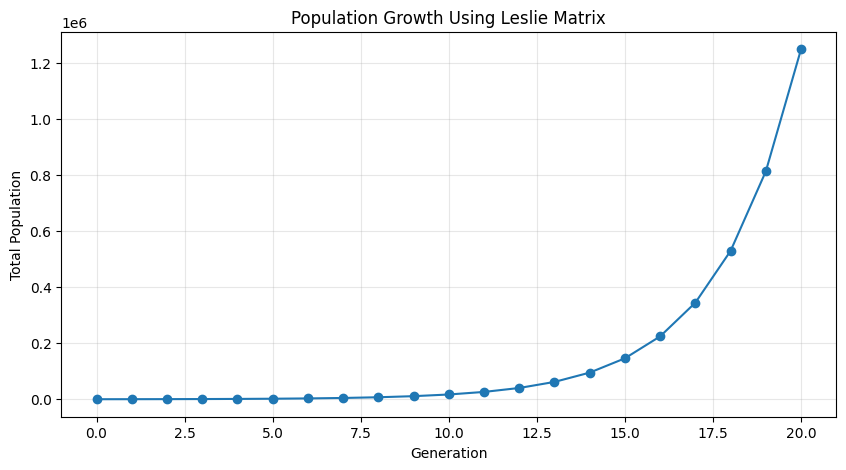

In [ ]:
# ============================================
# CELL 14: TOTAL POPULATION CHART
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(generations + 1),
    total_population,
    marker="o"
)

plt.xlabel("Generation")
plt.ylabel("Total Population")
plt.title("Population Growth Using Leslie Matrix")

plt.grid(True, alpha=0.3)
plt.show()

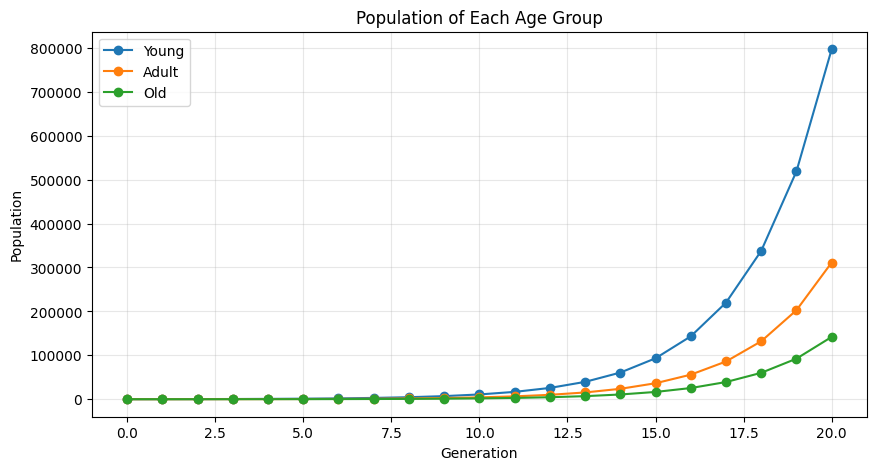

In [ ]:
# ============================================
# CELL 15: AGE-GROUP POPULATION CHART
# ============================================

plt.figure(figsize=(10, 5))

for i, age in enumerate(age_groups):
    plt.plot(
        range(generations + 1),
        population_history[:, i],
        marker="o",
        label=age
    )

plt.xlabel("Generation")
plt.ylabel("Population")
plt.title("Population of Each Age Group")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

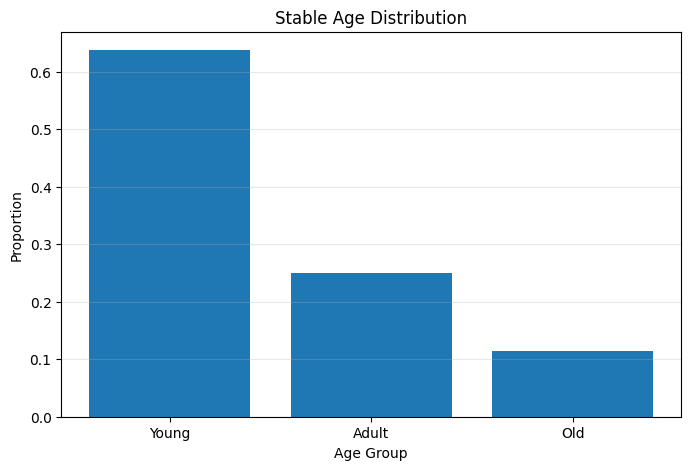

In [ ]:
# ============================================
# CELL 16: STABLE AGE DISTRIBUTION CHART
# ============================================

plt.figure(figsize=(8, 5))

plt.bar(
    age_groups,
    stable_distribution
)

plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.title("Stable Age Distribution")

plt.grid(axis="y", alpha=0.3)

plt.show()

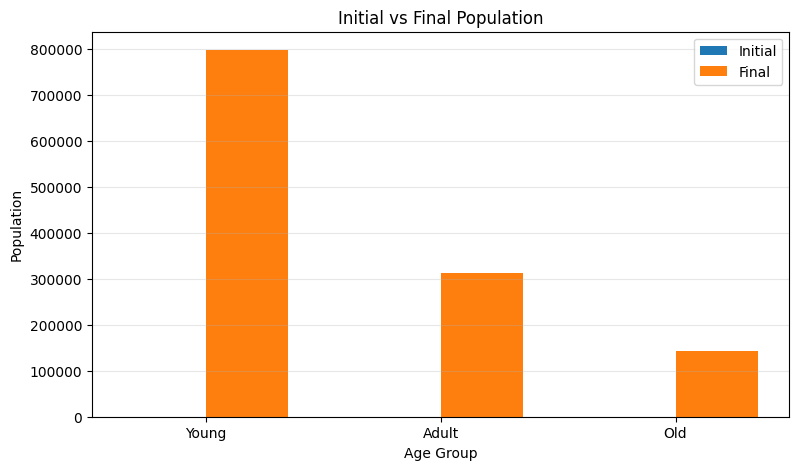

In [ ]:
# ============================================
# CELL 17: INITIAL VS FINAL POPULATION
# ============================================

x = np.arange(len(age_groups))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    initial_population,
    width,
    label="Initial"
)

plt.bar(
    x + width/2,
    population_history[-1],
    width,
    label="Final"
)

plt.xticks(x, age_groups)
plt.xlabel("Age Group")
plt.ylabel("Population")
plt.title("Initial vs Final Population")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# ============================================
# CELL 18: FINAL SUMMARY
# ============================================

print("\n" + "=" * 60)
print("       POPULATION GROWTH MODEL - LESLIE MATRIX")
print("=" * 60)

print(f"\nDominant eigenvalue (λ): {lambda_dominant:.6f}")
print(f"Population status: {status}")

print("\nStable Age Distribution:")
for age, proportion in zip(age_groups, stable_distribution):
    print(f"  {age:10s}: {proportion*100:6.2f}%")

print("\nInitial population:", initial_population.sum())
print("Final population:  ", round(total_population[-1], 2))

print("\nMathematical validation:")
print(f"  Maximum |Av - λv| = {max_error:.10f}")

print("\nConclusion:")
print(explanation)

print("=" * 60)


       POPULATION GROWTH MODEL - LESLIE MATRIX

Dominant eigenvalue (λ): 1.535866
Population status: GROWING

Stable Age Distribution:
  Young     :  63.75%
  Adult     :  24.90%
  Old       :  11.35%

Initial population: 230.0
Final population:   1250083.09

Mathematical validation:
  Maximum |Av - λv| = 0.0000000000

Conclusion:
The population is expected to grow in the long term.


In [ ]:
# ============================================
# CELL 19: BENCHMARK TEST DATASET
# ============================================

benchmark = {
    "F1": 0.5,
    "F2": 1.0,
    "F3": 1.4,
    "S1": 0.65,
    "S2": 0.75,
    "Initial Population": [120, 70, 40]
}

print("Benchmark Dataset")
print("-" * 30)

for key, value in benchmark.items():
    print(f"{key}: {value}")

Benchmark Dataset
------------------------------
F1: 0.5
F2: 1.0
F3: 1.4
S1: 0.65
S2: 0.75
Initial Population: [120, 70, 40]


In [ ]:
# ============================================
# CELL 20: BENCHMARK CALCULATION
# ============================================

A_test = np.array([
    [benchmark["F1"], benchmark["F2"], benchmark["F3"]],
    [benchmark["S1"], 0, 0],
    [0, benchmark["S2"], 0]
], dtype=float)

test_eigenvalues, test_eigenvectors = np.linalg.eig(A_test)

test_index = np.argmax(np.abs(test_eigenvalues))

test_lambda = np.real(test_eigenvalues[test_index])

test_v = np.real(test_eigenvectors[:, test_index])

# Make eigenvector positive
if np.sum(test_v) < 0:
    test_v = -test_v

test_stable_distribution = test_v / np.sum(test_v)

print("Benchmark Leslie Matrix:")
print(A_test)

print("\nBenchmark dominant eigenvalue:")
print(f"λ = {test_lambda:.6f}")

print("\nBenchmark stable age distribution:")

for age, value in zip(age_groups, test_stable_distribution):
    print(f"{age}: {value*100:.2f}%")

if test_lambda > 1:
    print("\nBenchmark result: GROWING")
elif test_lambda < 1:
    print("\nBenchmark result: DECLINING")
else:
    print("\nBenchmark result: STABLE")

Benchmark Leslie Matrix:
[[0.5  1.   1.4 ]
 [0.65 0.   0.  ]
 [0.   0.75 0.  ]]

Benchmark dominant eigenvalue:
λ = 1.353126

Benchmark stable age distribution:
Young: 57.25%
Adult: 27.50%
Old: 15.24%

Benchmark result: GROWING
